# Figure S4

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind

# for visualizing outliers
import os
import json
import base64
from PIL import Image
from io import BytesIO
import cv2

# for converting cielab to LCh
from colormath.color_objects import LabColor, LCHabColor
from colormath.color_conversions import convert_color

# for the 3d histogram
from mpl_toolkits.mplot3d import Axes3D
from skimage.color import lab2rgb

In [2]:
color_df = pd.read_csv('../datasets/1-clusters/geo_med.csv')

In [3]:
color_df_reduced = (
    color_df.groupby("gbifID", sort=False, group_keys=False)
    .apply(lambda x: x.sample(1,random_state=123))
    .reset_index(drop=True)
)
color_df_reduced

/var/folders/qh/c7rwx84921n2kznn09zb2pnh0000gn/T/ipykernel_98231/1712891894.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1,random_state=123))


,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035
...,...,...,...,...,...,...,...,...,...
16582,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552
16583,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277
16584,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752
16585,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498


### add separate component rows

In [4]:
L = [(int(i.strip('()').split(', ')[0])) for i in color_df_reduced.lab]
L = (np.array(L) / 255.0) * 100.0  
color_df_reduced['L'] = L
a = [(int(i.strip('()').split(', ')[1])) for i in color_df_reduced.lab]
a = np.array(a) - 128.0  
color_df_reduced['a'] = a
b = [(int(i.strip('()').split(', ')[2])) for i in color_df_reduced.lab]
b = np.array(b) - 128.0
color_df_reduced['b'] = b

### All

In [5]:
lab_raw = color_df_reduced[["L", "a", "b"]].to_numpy().astype(float)

In [6]:
lab_raw

array([[ 77.25490196,  20.        , -19.        ],
       [ 75.68627451,  14.        , -10.        ],
       [ 71.37254902,  18.        , -22.        ],
       ...,
       [ 65.88235294,  20.        , -24.        ],
       [ 76.07843137,   3.        ,   5.        ],
       [ 60.        ,  24.        , -22.        ]], shape=(16587, 3))

#### Lab

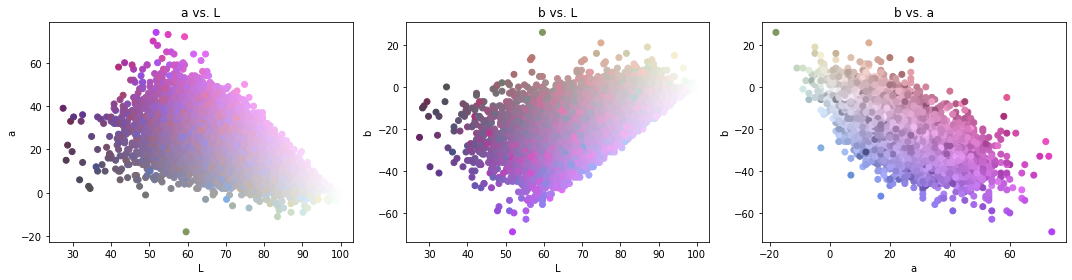

In [7]:
L, a, b = lab_raw.T

fig, axes = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

axes[0].scatter(L, a, alpha=1,c=color_df_reduced.hex)
axes[0].set_xlabel('L'); axes[0].set_ylabel('a'); axes[0].set_title('a vs. L')

axes[1].scatter(L, b, alpha=1,c=color_df_reduced.hex)
axes[1].set_xlabel('L'); axes[1].set_ylabel('b'); axes[1].set_title('b vs. L')

axes[2].scatter(a, b, alpha=1,c=color_df_reduced.hex)
axes[2].set_xlabel('a'); axes[2].set_ylabel('b'); axes[2].set_title('b vs. a')

plt.savefig('../figures/figures_current/components/figure_s4_Lab.pdf',dpi=300)

plt.show()

#### LCh

In [8]:
lab_raw = color_df_reduced[["L", "a", "b"]].to_numpy().astype(float)

lab_true = lab_raw.copy()

lch_arr = np.empty_like(lab_true)
for i, (L_, a_, b_) in enumerate(lab_true):
    # had to think carefully here -- these look like the correct defaults
    # rather than d50 illuminant because of I used opencv at its default
    lab = LabColor(L_, a_, b_, observer='2', illuminant='d65') 
    lch = convert_color(lab, LCHabColor)
    lch_arr[i] = lch.get_value_tuple()

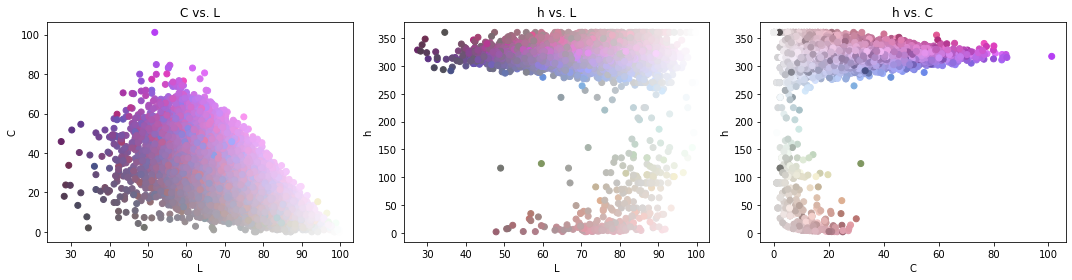

In [9]:
L, C, h = lch_arr.T

fig, axes = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

axes[0].scatter(L, C, alpha=1,c=color_df_reduced.hex)
axes[0].set_xlabel('L'); axes[0].set_ylabel('C'); axes[0].set_title('C vs. L')

axes[1].scatter(L, h, alpha=1,c=color_df_reduced.hex)
axes[1].set_xlabel('L'); axes[1].set_ylabel('h'); axes[1].set_title('h vs. L')

axes[2].scatter(C, h, alpha=1,c=color_df_reduced.hex)
axes[2].set_xlabel('C'); axes[2].set_ylabel('h'); axes[2].set_title('h vs. C')

plt.savefig('../figures/figures_current/components/figure_s4_LCh.pdf',dpi=300)

plt.show()